In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from arch import arch_model
from arch.univariate import ARX
from scipy.stats import norm

### Import data

In [2]:
path = os.path.abspath('E:/RA/Geert/task1.py')
dir_path = os.path.dirname(path)
os.chdir(dir_path)
excel_file = pd.ExcelFile('Aggregate_CPI_inflation_20230513.xls')
sheet_quarter = excel_file.sheet_names[0]
sheet_month = excel_file.sheet_names[1]
#quarterly and monthly aggregate CPI data (deseasonalized). The full sample is 1947-2022
data_quarter = excel_file.parse(sheet_quarter, skiprows=2)
data_month = excel_file.parse(sheet_month, skiprows=2)
data_quarter.index = pd.to_datetime(data_quarter['Year'].astype(str) + '-Q' + data_quarter['Quarter'].astype(str))
data_month.index = pd.to_datetime(data_month[['Year', 'Month']].assign(day=1))
data_quarter.columns = ['Year', 'Quarter', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
data_month.columns = ['Year', 'Month', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
sample_data = data_quarter[data_quarter['Year']>1969]

In [5]:
sample_data['Inflation_lag_1'] =  sample_data['Inflation'].shift(1)
sample_data['Inflation_lag_2'] =  sample_data['Inflation'].shift(2)
sample_data['Forecasted_inflation_lag_1'] =  sample_data['Forecasted inflation'].shift(1)
sample_data = sample_data.dropna()

 ### GARCH model specification

GARCH(p,q) model specification:
$$
 \sigma_{t}^{2}=\omega +\sum_{i=1}^{p}\alpha_{i} \epsilon_{t-i}^2
         +\sum_{k=1}^{q}\beta_{k}\sigma_{t-k}^{2} 
$$

EGARCH(p,q) model specification:
$$
 \ln\sigma_{t}^{2}=\omega +\sum_{i=1}^{p}[ \alpha_{i}  \left(\left|e_{t-i}\right|-\sqrt{2/\pi}\right)
        +\gamma_{i} e_{t-i}] +\sum_{k=1}^{q}\beta_{k}\ln\sigma_{t-k}^{2} 
$$
where :
$e_{t}=\epsilon_{t}/\sigma_{t}$

GJR-GARCH model specification:
$$
\sigma_{t}^{2}=\omega  + \sum_{i=1}^{p}\left(\alpha_{i}\epsilon_{t-i}^{2}
        +\gamma_{i}\epsilon_{t-i}^{2}
        I\left[\epsilon_{t-i}<0\right]\right)+\sum_{k=1}^{q}\beta_{k}\sigma_{t-k}^{2}
$$


 ### Distribution specification

**Student's T distribution**

One parameter : $\nu$

Log Likelihood Function of one residual $\epsilon_t$ with conditional standard error $\sigma_t$ :
\begin{align}
            \ln\Gamma\left(\frac{\nu+1}{2}\right)
            -\ln\Gamma\left(\frac{\nu}{2}\right)
            -\frac{1}{2}\ln(\pi\left(\nu-2\right)\sigma_t^{2})
            -\frac{\nu+1}{2}\ln(1+\epsilon_t^{2}/(\sigma_t^{2}(\nu-2)))
\end{align}
        where $\Gamma$ is the gamma function.

**Standardized Skewed Student's distribution**  
 
Two parameters, $\eta$ and $\lambda$. 
 
 $\eta$ controls the tail shape and is similar to the shape parameter in a Standardized Student's t.
    
$\lambda$ controls the skewness. When $\lambda=0$ the   distribution is identical to a standardized Student's t.


The log-likelihood of a single data point $\epsilon_t$ with conditional standard error $\sigma_t$ is

\begin{align}
\ln\left[\frac{bc}{\sigma_t}\left(1+\frac{1}{\eta-2}
        \left(\frac{a+b\epsilon_t/\sigma_t}
       {1+sgn(\epsilon_t/\sigma_t+a/b)\lambda}\right)^{2}\right)^{-\left(\eta+1\right)/2}\right],
\end{align}
  where $2<\eta<\infty$, and $-1<\lambda<1$.
        The constants $a$,$b$, and $c$ are given by

\begin{align}
   a=4\lambda c\frac{\eta-2}{\eta-1},
       \quad b^{2}=1+3\lambda^{2}-a^{2},
       \quad c=\frac{\Gamma\left(\frac{\eta+1}{2}\right)}
         {\sqrt{\pi\left(\eta-2\right)}
         \Gamma\left(\frac{\eta}{2}\right)},
\end{align}

**GED**

One parameter : $\nu$

The log-likelihood of a single data point $\epsilon_t$ with conditional standard error $\sigma_t$ is

\begin{align}
            \ln\nu-\ln c-\ln\Gamma(\frac{1}{\nu})-(1+\frac{1}{\nu})\ln2
            -\frac{1}{2}\ln\sigma^{2}
            -\frac{1}{2}\left|\frac{\epsilon_t}{c\sigma_t}\right|^{\nu}
\end{align}
        where $\Gamma$ is the gamma function and $\ln c$ is

\begin{align}
            \ln c=\frac{1}{2}\left(\frac{-2}{\nu}\ln2+\ln\Gamma(\frac{1}{\nu})
            -\ln\Gamma(\frac{3}{\nu})\right).
\end{align}

There are no additional options related to distributions. We can only choose a distribution.

### Mean model and Variance model are jointly estimated. 

In [11]:
def GarchFamilyResults(Y,X=None,mean='Zero',lags=None, cov = 'robust'):
    name_dict = {'normal':'Normal Distribution','studentst':'Standard Student t distribution','skewstudent':'Skew Student t distribution','generalized error':'Generalized Error distribution'}
    options = {'maxiter': 1000}
    
    for dist in name_dict:
        print('\n\nFollowing results are using ',name_dict[dist])
        garch11 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=1, q=1,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        garch21 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, q=1,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        garch12 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=1, q=2,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        garch22 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, q=2,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        print('\nGARCH(p,q) model')
        print('\t \t AIC: \t \t \t BIC',
              '\nGARCH(1,1): ',garch11.aic,'\t',garch11.bic,
              '\nGARCH(2,1): ',garch21.aic,'\t',garch21.bic,
              '\nGARCH(1,2): ',garch12.aic,'\t',garch12.bic,
              '\nGARCH(2,2): ',garch22.aic,'\t',garch22.bic,)

        egarch11 = arch_model(y=Y,x=X, mean=mean, vol='EGARCH',p=1, o=1, q=1,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        egarch12 = arch_model(y=Y,x=X, mean=mean, vol='EGARCH',p=1, o=1, q=2,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        egarch21 = arch_model(y=Y,x=X, mean=mean, vol='EGARCH',p=2, o=2, q=1,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        egarch22 = arch_model(y=Y,x=X, mean=mean, vol='EGARCH',p=2, o=2, q=2,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        print('\nEGARCH(p,q) model')
        print('\t \t AIC: \t \t \t BIC',
              '\nEGARCH(1,1): ',egarch11.aic,'\t',egarch11.bic,
              '\nEGARCH(1,2): ',egarch12.aic,'\t',egarch12.bic,
              '\nEGARCH(2,1): ',egarch21.aic,'\t',egarch21.bic,
              '\nEGARCH(2,2): ',egarch22.aic,'\t',egarch22.bic,  )

        gjr_garch11 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=1, o=1,q=1,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        gjr_garch12 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=1, o=1,q=2,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        gjr_garch21 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, o=2,q=1,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        gjr_garch22 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, o=2,q=2,lags=lags,dist=dist).fit(disp='off',cov_type=cov,options=options)
        print('\nGJR-GARCH(p,q) model')
        print('\t \t AIC: \t \t \t BIC',
              '\nGJR-GARCH(1,1): ',gjr_garch11.aic,'\t',gjr_garch11.bic,
              '\nGJR-GARCH(1,2): ',gjr_garch12.aic,'\t',gjr_garch12.bic,
             '\nGJR-GARCH(2,1): ',gjr_garch21.aic,'\t',gjr_garch21.bic,
              '\nGJR-GARCH(2,2): ',gjr_garch22.aic,'\t',gjr_garch22.bic,)
    
    print('\n\nFollowing results are using Mixture of 2 Normals Distribution')
    dparams=[0.3,0.1,1]
    sparch11 = SPARCH(Y=Y,dparams=dparams,X=X,mean=mean, vol='GARCH',p=1,q=1,lags=lags)
    sparch21 = SPARCH(Y=Y,dparams=dparams,X=X,mean=mean, vol='GARCH',p=2,q=1,lags=lags)
    sparch12 = SPARCH(Y=Y,dparams=dparams,X=X,mean=mean, vol='GARCH',p=1,q=2,lags=lags)   
    sparch22 = SPARCH(Y=Y,dparams=dparams,X=X,mean=mean, vol='GARCH',p=2,q=2,lags=lags)
    print('\nSPARCH(p,q) model')
    print('\t \t AIC: \t \t \t BIC',
          '\nGARCH(1,1): ',sparch11.aic,'\t',sparch11.bic,
          '\nGARCH(2,1): ',sparch21.aic,'\t',sparch21.bic,
          '\nGARCH(1,2): ',sparch12.aic,'\t',sparch12.bic,
          '\nGARCH(2,2): ',sparch22.aic,'\t',sparch22.bic,)
    
 
    sparch11 = SPARCH(Y=Y,dparams=dparams,X=X,mean=mean, vol='GARCH',p=1,o=1,q=1,lags=lags)
    sparch21 = SPARCH(Y=Y,dparams=dparams,X=X,mean=mean, vol='GARCH',p=2,o=1,q=1,lags=lags)
    sparch12 = SPARCH(Y=Y,dparams=dparams,X=X,mean=mean, vol='GARCH',p=1,o=1,q=2,lags=lags)   
    sparch22 = SPARCH(Y=Y,dparams=dparams,X=X,mean=mean, vol='GARCH',p=2,o=2,q=2,lags=lags)
    print('\nSPARCH(p,q) model')
    print('\t \t AIC: \t \t \t BIC',
          '\nGJR-GARCH(1,1): ',sparch11.aic,'\t',sparch11.bic,
          '\nGJR-GARCH(2,1): ',sparch21.aic,'\t',sparch21.bic,
          '\nGJR-GARCH(1,2): ',sparch12.aic,'\t',sparch12.bic,
          '\nGJR-GARCH(2,2): ',sparch22.aic,'\t',sparch22.bic,) 

## Panel of AIC & BIC

Summary:

SPARCH performs better than GARCH with normal distribution, worse than t distribution, and similar than skew t distribution and GED

$
\pi (t) =  fc(t-1) + \epsilon (t)
$

In [12]:
GarchFamilyResults(Y = sample_data['Inflation shock'],mean='Zero')



Following results are using  Normal Distribution

GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  386.4142136560987 	 396.39784216246744 
GARCH(2,1):  371.5712471475516 	 384.88275182270996 
GARCH(1,2):  388.4142136366495 	 401.72571831180784 
GARCH(2,2):  373.5712464889966 	 390.2106273329445

EGARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
EGARCH(1,1):  368.00522919611274 	 381.3167338712711 
EGARCH(1,2):  370.0052289622213 	 386.64460980616917 
EGARCH(2,1):  360.68066427315506 	 380.64792128589255 
EGARCH(2,2):  362.6806651151302 	 385.9757982966573

GJR-GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  370.6844496195249 	 383.99595429468326 
GJR-GARCH(1,2):  372.6844496924209 	 389.3238305363688 
GJR-GARCH(2,1):  359.88846740711483 	 379.8557244198523 
GJR-GARCH(2,2):  361.8884676340026 	 385.1836008155297


Following results are using  Standard Student t distribution

GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  353.9971954159586 	 367.3087000911169 
GARCH(2,1):  351.9608392518

D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outs


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  357.75561924591295 	 377.72287625865044 
GARCH(2,1):  354.7887104357062 	 378.0838436172333 
GARCH(1,2):  359.7556188979564 	 383.0507520794835 
GARCH(2,2):  356.7887105902066 	 383.41171994052326


D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bo


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  349.10100336267624 	 372.39613654420333 
GJR-GARCH(2,1):  351.1010032048257 	 377.72401255514234 
GJR-GARCH(1,2):  352.169230216163 	 378.7922395664796 
GJR-GARCH(2,2):  348.2120718243124 	 381.49083351220816


D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


$
\pi (t) = c +\rho \pi (t-1)   + \phi fc(t-1) + \epsilon (t)
$

In [13]:
GarchFamilyResults(Y = sample_data['Inflation'],X=sample_data['Forecasted inflation'],mean='ARX',lags=[1])



Following results are using  Normal Distribution

GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  381.70531975298735 	 401.6433796278178 
GARCH(2,1):  372.32218227742993 	 395.5832521313988 
GARCH(1,2):  383.70532007187603 	 406.9663899258449 
GARCH(2,2):  374.32218251160936 	 400.90626234471665

EGARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
EGARCH(1,1):  365.8641784163111 	 389.12524827028 
EGARCH(1,2):  367.86422712168064 	 394.4483069547879 
EGARCH(2,1):  358.95172699350906 	 388.8588168057547 
EGARCH(2,2):  360.95716257692743 	 394.1872623683115

GJR-GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  367.1245106180395 	 390.38558047200837 
GJR-GARCH(1,2):  369.1245104640634 	 395.70859029717064 
GJR-GARCH(2,1):  358.0338965832879 	 387.94098639553357 
GJR-GARCH(2,2):  360.03389669575483 	 393.2639964871389


Following results are using  Standard Student t distribution

GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  348.4845882704359 	 371.74565812440477 
GARCH(2,1):  347.70885572

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bo


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  353.8040541426808 	 383.71114395492646 
GARCH(2,1):  352.3601608722724 	 385.59026066365647 
GARCH(1,2):  355.8040544605112 	 389.0341542518953 
GARCH(2,2):  354.3601614659558 	 390.9132712364783


D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bo


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  346.93490865535216 	 380.16500844673624 
GJR-GARCH(2,1):  348.9349076038359 	 385.4880173743584 
GJR-GARCH(1,2):  348.9349077188766 	 385.4880174893991 
GJR-GARCH(2,2):  346.6043558878141 	 389.80348561661344


$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi fc(t-1) + \epsilon (t)
$

In [16]:
GarchFamilyResults(Y = sample_data['Inflation'],X=sample_data['Forecasted inflation'],mean='ARX',lags=[1,2])



Following results are using  Normal Distribution

GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  381.42991828166544 	 404.656758238575 
GARCH(2,1):  373.4200404148385 	 399.96500036559223 
GARCH(1,2):  383.42991836017575 	 409.97487831092945 
GARCH(2,2):  375.4200409553805 	 405.2831208999784

EGARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
EGARCH(1,1):  366.93615190425817 	 393.4811118550119 
EGARCH(1,2):  368.9361517454101 	 398.799231690008 
EGARCH(2,1):  360.29649477277854 	 393.4776947112207 
EGARCH(2,2):  362.28835003953077 	 398.78766997181714

GJR-GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  368.2227491935031 	 394.7677091442568 
GJR-GARCH(1,2):  370.2227491314678 	 400.08582907606575 
GJR-GARCH(2,1):  359.5859977416595 	 392.7671976801017 
GJR-GARCH(2,2):  361.5859982625708 	 398.08531819485717


Following results are using  Standard Student t distribution

GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  349.23328190071356 	 375.77824185146727 
GARCH(2,1):  348.698396100

D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outs


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  352.8438851400956 	 386.02508507853776 
GARCH(2,1):  352.46969298310114 	 388.9690129153875 
GARCH(1,2):  354.8438842863768 	 391.3432042186632 
GARCH(2,2):  354.4930239181032 	 394.31046384423377


D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outs


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  347.9332771390392 	 384.4325970713256 
GJR-GARCH(2,1):  349.9332781345886 	 389.7507180607192 
GJR-GARCH(1,2):  349.9332770942858 	 389.7507170204164 
GJR-GARCH(2,2):  348.01035981547284 	 394.46403972929187


$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi_1 fc(t-1) + \phi_2 fc(t-2) + \epsilon (t)
$

In [17]:
GarchFamilyResults(Y = sample_data['Inflation'],X=sample_data[['Forecasted inflation','Forecasted_inflation_lag_1']],mean='ARX',lags=[1,2])



Following results are using  Normal Distribution

GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  383.42071938025845 	 409.96567933101215 
GARCH(2,1):  375.40799058623713 	 405.27107053083506 
GARCH(1,2):  385.4207193557636 	 415.2837993003615 
GARCH(2,2):  377.407988958859 	 410.58918889730114

EGARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
EGARCH(1,1):  368.4933087148247 	 398.35638865942263 
EGARCH(1,2):  370.4935007115388 	 403.67470064998093 
EGARCH(2,1):  361.71495711836997 	 398.21427705065634 
EGARCH(2,2):  363.7149563806176 	 403.5323963067482

GJR-GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  370.2289324527824 	 400.0920123973803 
GJR-GARCH(1,2):  372.2289325079847 	 405.41013244642687 
GJR-GARCH(2,1):  361.5373565696508 	 398.03667650193717 
GJR-GARCH(2,2):  363.537356749403 	 403.3547966755336


Following results are using  Standard Student t distribution

GARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  351.2048754593721 	 381.06795540397 
GARCH(2,1):  350.697798747058

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bo


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GARCH(1,1):  354.79314141539254 	 391.2924613476789 
GARCH(2,1):  354.43528731179174 	 394.25272723792233 
GARCH(1,2):  356.79314165065307 	 396.61058157678366 
GARCH(2,2):  356.4775805492472 	 399.613140469222


D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outs


SPARCH(p,q) model
	 	 AIC: 	 	 	 BIC 
GJR-GARCH(1,1):  349.883080923549 	 389.7005208496796 
GJR-GARCH(2,1):  351.8830812402516 	 395.0186411602264 
GJR-GARCH(1,2):  351.88308157972705 	 395.01864149970186 
GJR-GARCH(2,2):  349.8423385478219 	 399.61413845548515


### Present MLE details of best garch model in each mean models

Summary: GJR GARCH(2,1) with student's t distribution wins under AIC criterion, but EGARCH(1,1) with student's t distribution wins under BIC criterion

$
\pi (t) =  fc(t-1) + \epsilon (t)
$

In [47]:
print('Based on AIC, the best one is GJR GARCH(2,1) with student t distribution')
gjr_garch21 = arch_model(y=sample_data['Inflation shock'],mean='Zero', vol='GARCH',p=2, o=2,q=1,dist = 'studentst').fit(cov_type='robust')
gjr_garch21.summary()

Based on AIC, the best one is GJR GARCH(2,1) with student t distribution
Iteration:      1,   Func. Count:      9,   Neg. LLF: 1059.2480705903863
Iteration:      2,   Func. Count:     18,   Neg. LLF: 361.4208285990386
Iteration:      3,   Func. Count:     28,   Neg. LLF: 182.3912077139476
Iteration:      4,   Func. Count:     37,   Neg. LLF: 176.1067498280596
Iteration:      5,   Func. Count:     46,   Neg. LLF: 172.9383585441007
Iteration:      6,   Func. Count:     55,   Neg. LLF: 177.73311238921468
Iteration:      7,   Func. Count:     64,   Neg. LLF: 168.76468750438636
Iteration:      8,   Func. Count:     73,   Neg. LLF: 170.00896267372696
Iteration:      9,   Func. Count:     82,   Neg. LLF: 168.00839523498007
Iteration:     10,   Func. Count:     91,   Neg. LLF: 166.8306511724226
Iteration:     11,   Func. Count:     99,   Neg. LLF: 166.82095617680724
Iteration:     12,   Func. Count:    107,   Neg. LLF: 166.81543313417757
Iteration:     13,   Func. Count:    115,   Neg. LLF: 16

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Zero Mean - GJR-GARCH Model Results                         
====================================================================================
Dep. Variable:              Inflation shock   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.005
Vol Model:                        GJR-GARCH   Log-Likelihood:               -166.805
Distribution:      Standardized Student's t   AIC:                           347.610
Method:                  Maximum Likelihood   BIC:                           370.973
                                              No. Observations:                  208
Date:                      Tue, Jul 18 2023   Df Residuals:                      208
Time:                              22:43:13   Df Model:                            0
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1034  3.329e-02      3.106  1.893e-03  [3.817e-02,  0.169]
alpha[1]       0.4484      0.194      2.308  2.102e-02  [6.757e-02,  0.829]
alpha[2]       0.7420      0.298      2.491  1.275e-02    [  0.158,  1.326]
gamma[1]      -0.1674      0.235     -0.713      0.476    [ -0.628,  0.293]
gamma[2]      -0.7420      0.288     -2.576  9.993e-03    [ -1.307, -0.177]
beta[1]        0.0980  9.150e-02      1.071      0.284 [-8.133e-02,  0.277]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.4054      2.004      2.697  6.996e-03 [  1.477,  9.334]
========================================================================

Covariance estimator: robust
"""

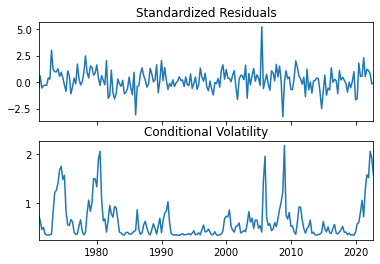

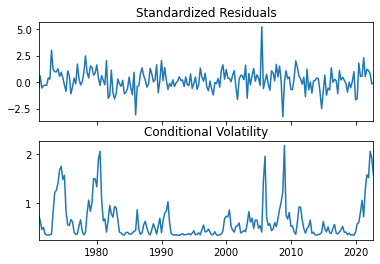

In [48]:
gjr_garch21.plot()

In [49]:
print('Based on BIC, the best one is EGARCH(1,1) with student t distribution')
gjr_garch21 = arch_model(y=sample_data['Inflation shock'],mean='Zero',  vol='EGARCH',p=1, o=1, q=1,dist = 'studentst').fit(cov_type='robust')
gjr_garch21.summary()

Based on BIC, the best one is EGARCH(1,1) with student t distribution
Iteration:      1,   Func. Count:      7,   Neg. LLF: 3087.192136689776
Iteration:      2,   Func. Count:     17,   Neg. LLF: 1932.7482951266097
Iteration:      3,   Func. Count:     26,   Neg. LLF: 2369.624203421867
Iteration:      4,   Func. Count:     34,   Neg. LLF: 214.6269915382373
Iteration:      5,   Func. Count:     42,   Neg. LLF: 170.26351835866575
Iteration:      6,   Func. Count:     48,   Neg. LLF: 170.24524776055642
Iteration:      7,   Func. Count:     54,   Neg. LLF: 170.24367623644446
Iteration:      8,   Func. Count:     60,   Neg. LLF: 170.24305045377977
Iteration:      9,   Func. Count:     66,   Neg. LLF: 170.2428220472013
Iteration:     10,   Func. Count:     72,   Neg. LLF: 170.24275542977873
Iteration:     11,   Func. Count:     78,   Neg. LLF: 170.24275022551373
Iteration:     12,   Func. Count:     83,   Neg. LLF: 170.24275022551342
Optimization terminated successfully    (Exit mode 0)
    

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Zero Mean - EGARCH Model Results                          
====================================================================================
Dep. Variable:              Inflation shock   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.005
Vol Model:                           EGARCH   Log-Likelihood:               -170.243
Distribution:      Standardized Student's t   AIC:                           350.486
Method:                  Maximum Likelihood   BIC:                           367.173
                                              No. Observations:                  208
Date:                      Tue, Jul 18 2023   Df Residuals:                      208
Time:                              22:43:18   Df Model:                            0
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega         -0.2292      0.115     -1.989  4.669e-02 [ -0.455,-3.355e-03]
alpha[1]       0.5672      0.143      3.967  7.287e-05    [  0.287,  0.847]
gamma[1]       0.2740  8.025e-02      3.414  6.397e-04    [  0.117,  0.431]
beta[1]        0.7953  6.345e-02     12.534  4.844e-36    [  0.671,  0.920]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             4.6916      1.576      2.977  2.908e-03 [  1.603,  7.780]
========================================================================

Covariance estimator: robust
"""

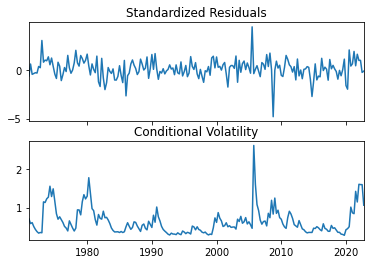

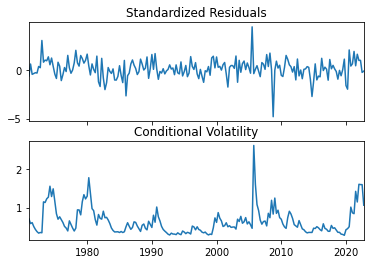

In [50]:
gjr_garch21.plot()

$
\pi (t) = c +\rho \pi (t-1)   + \phi fc(t-1) + \epsilon (t)
$

In [51]:
print('Based on AIC, the best one is GJR GARCH(2,1) with student t distribution')
gjr_garch21 = arch_model(y=sample_data['Inflation'],x=sample_data['Forecasted inflation'], mean='ARX', p=2, o=2, q=1,dist='studentst',lags=[1]).fit(disp='off',cov_type='robust')
gjr_garch21.summary()

Based on AIC, the best one is GJR GARCH(2,1) with student t distribution


<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR-X - GJR-GARCH Model Results                           
====================================================================================
Dep. Variable:                    Inflation   R-squared:                       0.439
Mean Model:                            AR-X   Adj. R-squared:                  0.434
Vol Model:                        GJR-GARCH   Log-Likelihood:               -161.572
Distribution:      Standardized Student's t   AIC:                           343.143
Method:                  Maximum Likelihood   BIC:                           376.470
                                              No. Observations:                  207
Date:                      Tue, Jul 18 2023   Df Residuals:                      204
Time:                              22:43:24   Df Model:                            3
                                      Mean Model                                     
=====================================================================================
                           coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------------------------------------------------------------
Const                    0.0752  7.984e-02      0.941      0.346 [-8.132e-02,  0.232]
Inflation[1]             0.1650  9.202e-02      1.793  7.297e-02 [-1.536e-02,  0.345]
Forecasted inflation     0.8198      0.125      6.535  6.342e-11    [  0.574,  1.066]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1176  3.937e-02      2.987  2.818e-03  [4.043e-02,  0.195]
alpha[1]       0.4345      0.233      1.862  6.259e-02 [-2.285e-02,  0.892]
alpha[2]       0.7279      0.362      2.009  4.459e-02  [1.761e-02,  1.438]
gamma[1]      -0.1814      0.273     -0.664      0.506    [ -0.716,  0.354]
gamma[2]      -0.7279      0.327     -2.228  2.585e-02 [ -1.368,-8.768e-02]
beta[1]        0.1094      0.132      0.827      0.408    [ -0.150,  0.368]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.0181      1.881      2.668  7.636e-03 [  1.331,  8.705]
========================================================================

Covariance estimator: robust
"""

Correlation bewteen conditional mean and conditional volatiliy is  0.39348594532857517


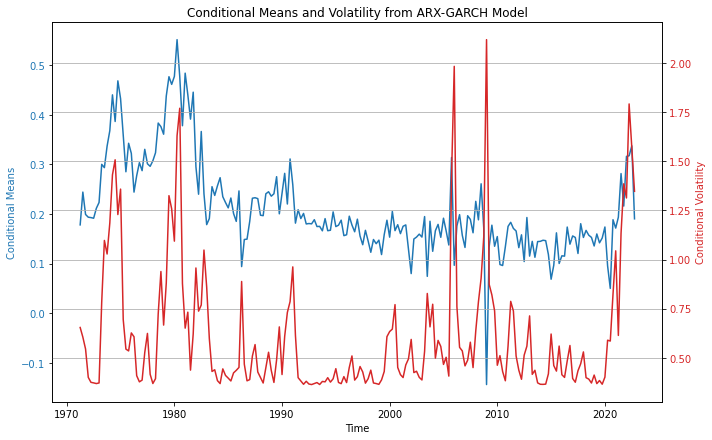

In [52]:
ar_coef = gjr_garch21.params['Const']
exog_coef = gjr_garch21.params['Const']
mu = gjr_garch21.params['Const']

conditional_means = mu + ar_coef * sample_data['Inflation'].shift(1) + exog_coef * sample_data['Forecasted inflation']

print("Correlation bewteen conditional mean and conditional volatiliy is ", np.corrcoef(conditional_means[3:], gjr_garch21.conditional_volatility[3:])[0, 1])
fig, ax1 = plt.subplots(figsize=(10,6))

color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Conditional Means', color=color)
ax1.plot(conditional_means, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Conditional Volatility', color=color)  # we already handled the x-label with ax1
ax2.plot(gjr_garch21.conditional_volatility, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Conditional Means and Volatility from ARX-GARCH Model')
plt.grid(True)
plt.show()

In [53]:
print('Based on BIC, the best one is EGARCH(1,1) with student t distribution')
gjr_garch21 = arch_model(y=sample_data['Inflation'],x=sample_data['Forecasted inflation'], mean='ARX',vol='EGARCH',p=1, o=1, q=1,dist='studentst',lags=[1]).fit(disp='off',cov_type='robust')
gjr_garch21.summary()

Based on BIC, the best one is EGARCH(1,1) with student t distribution


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AR-X - EGARCH Model Results                             
====================================================================================
Dep. Variable:                    Inflation   R-squared:                       0.441
Mean Model:                            AR-X   Adj. R-squared:                  0.435
Vol Model:                           EGARCH   Log-Likelihood:               -164.448
Distribution:      Standardized Student's t   AIC:                           344.896
Method:                  Maximum Likelihood   BIC:                           371.558
                                              No. Observations:                  207
Date:                      Tue, Jul 18 2023   Df Residuals:                      204
Time:                              22:43:30   Df Model:                            3
                                      Mean Model                                      
======================================================================================
                           coef    std err          t      P>|t|      95.0% Conf. Int.
--------------------------------------------------------------------------------------
Const                    0.0899  1.459e-03     61.607      0.000 [8.705e-02,9.277e-02]
Inflation[1]             0.1989  1.849e-03    107.571      0.000     [  0.195,  0.203]
Forecasted inflation     0.7555  6.620e-03    114.123      0.000     [  0.743,  0.769]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega         -0.2144      0.127     -1.692  9.063e-02 [ -0.463,3.395e-02]
alpha[1]       0.4885      0.159      3.064  2.183e-03   [  0.176,  0.801]
gamma[1]       0.2594  7.014e-02      3.698  2.172e-04   [  0.122,  0.397]
beta[1]        0.7867  7.855e-02     10.015  1.315e-23   [  0.633,  0.941]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             4.4344      1.485      2.987  2.817e-03 [  1.525,  7.344]
========================================================================

Covariance estimator: robust
"""

Correlation bewteen conditional mean and conditional volatiliy is  0.5378538418242099


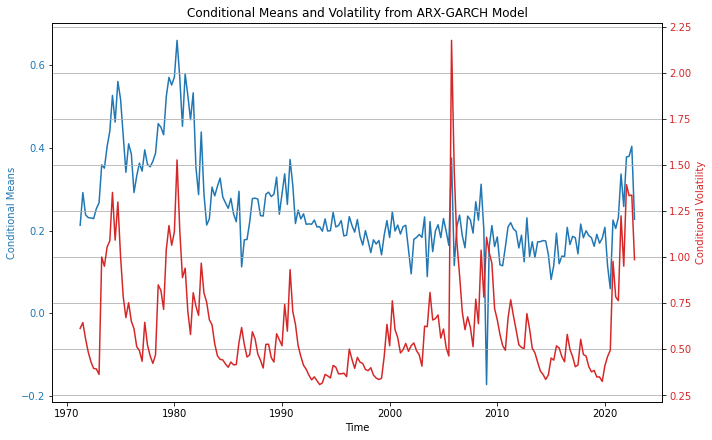

In [54]:
ar_coef = gjr_garch21.params['Const']
exog_coef = gjr_garch21.params['Const']
mu = gjr_garch21.params['Const']

conditional_means = mu + ar_coef * sample_data['Inflation'].shift(1) + exog_coef * sample_data['Forecasted inflation']

print("Correlation bewteen conditional mean and conditional volatiliy is ", np.corrcoef(conditional_means[3:], gjr_garch21.conditional_volatility[3:])[0, 1])
fig, ax1 = plt.subplots(figsize=(10,6))

color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Conditional Means', color=color)
ax1.plot(conditional_means, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Conditional Volatility', color=color)  # we already handled the x-label with ax1
ax2.plot(gjr_garch21.conditional_volatility, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Conditional Means and Volatility from ARX-GARCH Model')
plt.grid(True)
plt.show()

$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi fc(t-1) + \epsilon (t)
$

In [38]:
print('Based on AIC, the best one is GJR GARCH(2,1) with student t distribution')
gjr_garch21 = arch_model(y=sample_data['Inflation'],x=sample_data['Forecasted inflation'], mean='ARX', p=2, o=2, q=1,dist='studentst',lags=[1,2]).fit(disp='off',cov_type='robust')
gjr_garch21.summary()

Based on AIC, the best one is GJR GARCH(2,1) with student t distribution


<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR-X - GJR-GARCH Model Results                           
====================================================================================
Dep. Variable:                    Inflation   R-squared:                       0.445
Mean Model:                            AR-X   Adj. R-squared:                  0.437
Vol Model:                        GJR-GARCH   Log-Likelihood:               -160.772
Distribution:      Standardized Student's t   AIC:                           343.544
Method:                  Maximum Likelihood   BIC:                           380.151
                                              No. Observations:                  206
Date:                      Tue, Jul 18 2023   Df Residuals:                      202
Time:                              22:39:20   Df Model:                            4
                                      Mean Model                                     
=====================================================================================
                           coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------------------------------------------------------------
Const                    0.0753  8.905e-02      0.846      0.398 [-9.923e-02,  0.250]
Inflation[1]             0.1743  9.311e-02      1.872  6.123e-02 [-8.203e-03,  0.357]
Inflation[2]             0.0574      0.100      0.572      0.567    [ -0.139,  0.254]
Forecasted inflation     0.7483      0.159      4.718  2.379e-06    [  0.437,  1.059]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1138  3.862e-02      2.946  3.223e-03  [3.806e-02,  0.189]
alpha[1]       0.4210      0.238      1.769  7.695e-02 [-4.555e-02,  0.888]
alpha[2]       0.7201      0.368      1.955  5.061e-02 [-1.901e-03,  1.442]
gamma[1]      -0.1267      0.303     -0.418      0.676    [ -0.720,  0.467]
gamma[2]      -0.7201      0.333     -2.163  3.057e-02 [ -1.373,-6.750e-02]
beta[1]        0.1201      0.123      0.976      0.329    [ -0.121,  0.361]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             4.9781      1.800      2.766  5.678e-03 [  1.450,  8.506]
========================================================================

Covariance estimator: robust
"""

Correlation bewteen conditional mean and conditional volatiliy is  0.4181458580394257


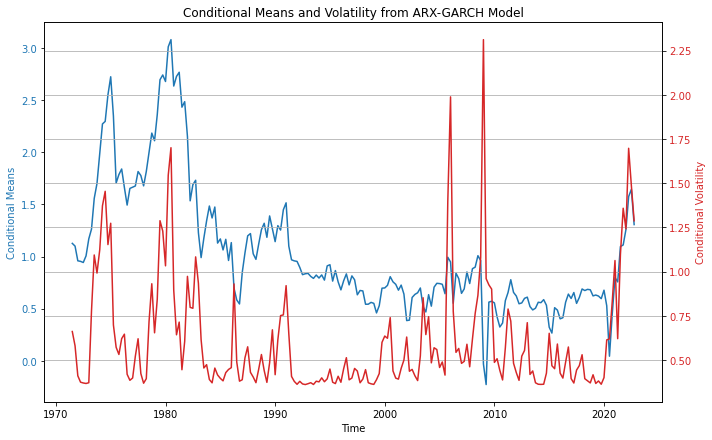

In [39]:
mu = gjr_garch21.params['Const']
ar1_coef = gjr_garch21.params['Inflation[1]']
ar2_coef = gjr_garch21.params['Inflation[1]']
exog_coef = gjr_garch21.params['Forecasted inflation']

# Calculate the conditional means
conditional_means = mu + ar1_coef * sample_data['Inflation'].shift(1) + ar2_coef * sample_data['Inflation'].shift(2) + exog_coef * sample_data['Forecasted inflation']
print("Correlation bewteen conditional mean and conditional volatiliy is ", np.corrcoef(conditional_means[3:], gjr_garch21.conditional_volatility[3:])[0, 1])

# Plotting both the series
fig, ax1 = plt.subplots(figsize=(10,6))

color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Conditional Means', color=color)
ax1.plot(conditional_means, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Conditional Volatility', color=color)  # we already handled the x-label with ax1
ax2.plot(gjr_garch21.conditional_volatility, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Conditional Means and Volatility from ARX-GARCH Model')
plt.grid(True)
plt.show()

In [40]:
print('Based on BIC, the best one is EGARCH(1,1) with student t distribution')
gjr_garch21 = arch_model(y=sample_data['Inflation'],x=sample_data['Forecasted inflation'], mean='ARX', vol='EGARCH',p=1, o=1, q=1,dist='studentst',lags=[1,2]).fit(disp='off',cov_type='robust')
gjr_garch21.summary()

Based on BIC, the best one is EGARCH(1,1) with student t distribution


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AR-X - EGARCH Model Results                             
====================================================================================
Dep. Variable:                    Inflation   R-squared:                       0.446
Mean Model:                            AR-X   Adj. R-squared:                  0.438
Vol Model:                           EGARCH   Log-Likelihood:               -163.313
Distribution:      Standardized Student's t   AIC:                           344.625
Method:                  Maximum Likelihood   BIC:                           374.576
                                              No. Observations:                  206
Date:                      Tue, Jul 18 2023   Df Residuals:                      202
Time:                              22:39:37   Df Model:                            4
                                      Mean Model                                     
=====================================================================================
                           coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------------------------------------------------------------
Const                    0.0861  6.839e-02      1.259      0.208 [-4.794e-02,  0.220]
Inflation[1]             0.2036  8.838e-02      2.304  2.124e-02  [3.037e-02,  0.377]
Inflation[2]             0.0738  9.756e-02      0.757      0.449    [ -0.117,  0.265]
Forecasted inflation     0.6728      0.147      4.570  4.876e-06    [  0.384,  0.961]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega         -0.1914      0.133     -1.436      0.151 [ -0.453,6.980e-02]
alpha[1]       0.5051      0.175      2.892  3.829e-03   [  0.163,  0.847]
gamma[1]       0.2365  8.623e-02      2.743  6.090e-03 [6.751e-02,  0.406]
beta[1]        0.8019  8.548e-02      9.382  6.500e-21   [  0.634,  0.969]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             4.3742      1.520      2.878  3.999e-03 [  1.396,  7.353]
========================================================================

Covariance estimator: robust
"""

Correlation bewteen conditional mean and conditional volatiliy is  0.46924036789742635


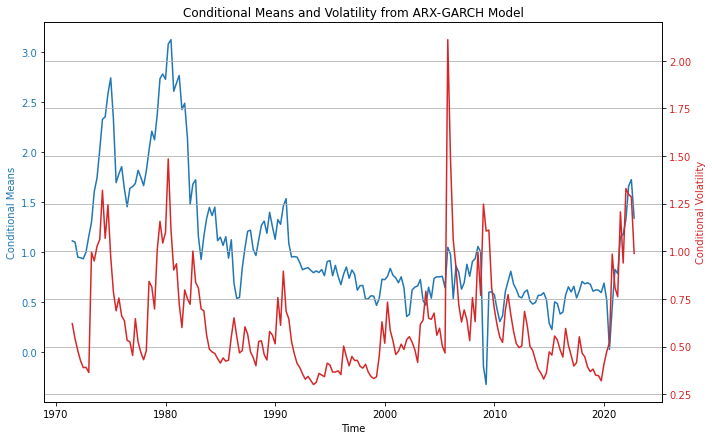

In [41]:
mu = gjr_garch21.params['Const']
ar1_coef = gjr_garch21.params['Inflation[1]']
ar2_coef = gjr_garch21.params['Inflation[1]']
exog_coef = gjr_garch21.params['Forecasted inflation']

# Calculate the conditional means
conditional_means = mu + ar1_coef * sample_data['Inflation'].shift(1) + ar2_coef * sample_data['Inflation'].shift(2) + exog_coef * sample_data['Forecasted inflation']
print("Correlation bewteen conditional mean and conditional volatiliy is ", np.corrcoef(conditional_means[3:], gjr_garch21.conditional_volatility[3:])[0, 1])

# Plotting both the series
fig, ax1 = plt.subplots(figsize=(10,6))

color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Conditional Means', color=color)
ax1.plot(conditional_means, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Conditional Volatility', color=color)  # we already handled the x-label with ax1
ax2.plot(gjr_garch21.conditional_volatility, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Conditional Means and Volatility from ARX-GARCH Model')
plt.grid(True)
plt.show()

$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi_1 fc(t-1) + \phi_2 fc(t-2) + \epsilon (t)
$

In [43]:
print('Based on AIC, the best one is EGARCH(2,1) with student t distribution')
gjr_garch21 = arch_model(y=sample_data['Inflation'],x=sample_data[['Forecasted inflation','Forecasted_inflation_lag_1']], mean='ARX', vol='EGARCH',p=2, o=2, q=1,dist='studentst',lags=[1,2]).fit(cov_type='robust')
gjr_garch21.summary()

Based on AIC, the best one is EGARCH(2,1) with student t distribution
Iteration:      1,   Func. Count:     14,   Neg. LLF: 1845.108878147059
Iteration:      2,   Func. Count:     32,   Neg. LLF: 9218.9272934937
Iteration:      3,   Func. Count:     48,   Neg. LLF: 4485.611416342134
Iteration:      4,   Func. Count:     64,   Neg. LLF: 4359.214404795848
Iteration:      5,   Func. Count:     80,   Neg. LLF: 4384.686188928002
Iteration:      6,   Func. Count:     95,   Neg. LLF: 3842.8780684335065
Iteration:      7,   Func. Count:    110,   Neg. LLF: 6099.0322993073405
Iteration:      8,   Func. Count:    125,   Neg. LLF: 270.8054858323479
Iteration:      9,   Func. Count:    140,   Neg. LLF: 388.0628130705263
Iteration:     10,   Func. Count:    155,   Neg. LLF: 2719.494048013413
Iteration:     11,   Func. Count:    170,   Neg. LLF: 160.7950327786513
Iteration:     12,   Func. Count:    183,   Neg. LLF: 161.34324507377227
Iteration:     13,   Func. Count:    197,   Neg. LLF: 160.6886117

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AR-X - EGARCH Model Results                             
====================================================================================
Dep. Variable:                    Inflation   R-squared:                       0.443
Mean Model:                            AR-X   Adj. R-squared:                  0.432
Vol Model:                           EGARCH   Log-Likelihood:               -160.677
Distribution:      Standardized Student's t   AIC:                           345.355
Method:                  Maximum Likelihood   BIC:                           385.289
                                              No. Observations:                  206
Date:                      Tue, Jul 18 2023   Df Residuals:                      201
Time:                              22:42:21   Df Model:                            5
                                         Mean Model                                        
===========================================================================================
                                 coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------------------------------------------------------------------
Const                          0.0894  6.567e-02      1.361      0.173 [-3.932e-02,  0.218]
Inflation[1]                   0.2081  9.806e-02      2.122  3.383e-02  [1.589e-02,  0.400]
Inflation[2]                   0.0455      0.121      0.376      0.707    [ -0.191,  0.282]
Forecasted inflation           0.5584      0.330      1.694  9.028e-02 [-8.770e-02,  1.205]
Forecasted_inflation_lag_1     0.1288      0.303      0.425      0.671    [ -0.465,  0.723]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega         -0.3234      0.205     -1.579      0.114 [ -0.725,7.804e-02]
alpha[1]       0.5744      0.164      3.494  4.766e-04   [  0.252,  0.897]
alpha[2]   5.7074e-03      0.260  2.197e-02      0.982   [ -0.504,  0.515]
gamma[1]       0.0690      0.129      0.537      0.591   [ -0.183,  0.321]
gamma[2]       0.2970      0.122      2.443  1.455e-02 [5.877e-02,  0.535]
beta[1]        0.7122      0.145      4.918  8.722e-07   [  0.428,  0.996]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             4.9058      1.753      2.798  5.140e-03 [  1.470,  8.342]
========================================================================

Covariance estimator: robust
"""

Correlation bewteen conditional mean and conditional volatiliy is  0.41147732834658335


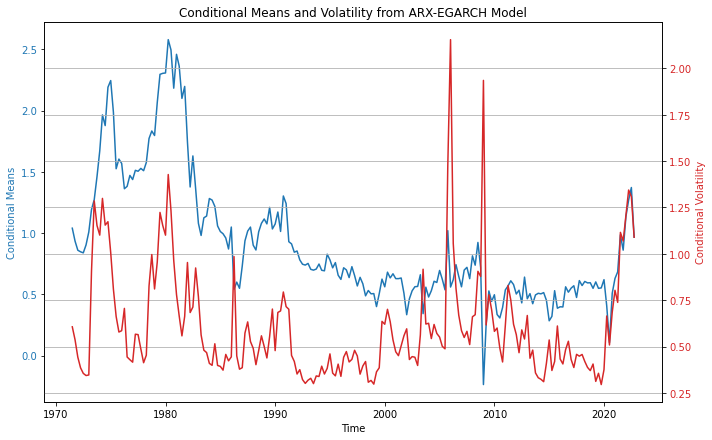

In [44]:
mu = gjr_garch21.params['Const']
ar1_coef = gjr_garch21.params['Inflation[1]']
ar2_coef = gjr_garch21.params['Inflation[2]']
exog1_coef = gjr_garch21.params['Forecasted inflation']
exog2_coef = gjr_garch21.params['Forecasted_inflation_lag_1']

# Calculate the conditional means
conditional_means = mu + ar1_coef * sample_data['Inflation'].shift(1) + ar2_coef * sample_data['Inflation'].shift(2) + exog1_coef * sample_data['Forecasted inflation'] + exog2_coef * sample_data['Forecasted_inflation_lag_1']
print("Correlation bewteen conditional mean and conditional volatiliy is ", np.corrcoef(conditional_means[3:], gjr_garch21.conditional_volatility[3:])[0, 1])

# Plotting both the series
fig, ax1 = plt.subplots(figsize=(10,6))

color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Conditional Means', color=color)
ax1.plot(conditional_means, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Conditional Volatility', color=color)  # we already handled the x-label with ax1
ax2.plot(gjr_garch21.conditional_volatility, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Conditional Means and Volatility from ARX-EGARCH Model')
plt.grid(True)
plt.show()


In [45]:
print('Based on BIC, the best one is EGARCH(1,1) with student t distribution')
gjr_garch21 = arch_model(y=sample_data['Inflation'],x=sample_data[['Forecasted inflation','Forecasted_inflation_lag_1']], mean='ARX', vol='EGARCH',p=1, o=1, q=1,dist='studentst',lags=[1,2]).fit(cov_type='robust')
gjr_garch21.summary()

Based on BIC, the best one is EGARCH(1,1) with student t distribution
Iteration:      1,   Func. Count:     12,   Neg. LLF: 3229.590293749716
Iteration:      2,   Func. Count:     28,   Neg. LLF: 5871.008562296848
Iteration:      3,   Func. Count:     42,   Neg. LLF: 1690.0969194208533
Iteration:      4,   Func. Count:     56,   Neg. LLF: 2513.953448227336
Iteration:      5,   Func. Count:     69,   Neg. LLF: 1334.4978616231879
Iteration:      6,   Func. Count:     82,   Neg. LLF: 715.3845079071749
Iteration:      7,   Func. Count:     95,   Neg. LLF: 211.99352048994498
Iteration:      8,   Func. Count:    108,   Neg. LLF: 182.39975616335028
Iteration:      9,   Func. Count:    121,   Neg. LLF: 163.99394570965822
Iteration:     10,   Func. Count:    133,   Neg. LLF: 164.19683051854074
Iteration:     11,   Func. Count:    145,   Neg. LLF: 163.2747943255731
Iteration:     12,   Func. Count:    157,   Neg. LLF: 163.24232740413498
Iteration:     13,   Func. Count:    168,   Neg. LLF: 163.2

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AR-X - EGARCH Model Results                             
====================================================================================
Dep. Variable:                    Inflation   R-squared:                       0.446
Mean Model:                            AR-X   Adj. R-squared:                  0.435
Vol Model:                           EGARCH   Log-Likelihood:               -163.235
Distribution:      Standardized Student's t   AIC:                           346.469
Method:                  Maximum Likelihood   BIC:                           379.748
                                              No. Observations:                  206
Date:                      Tue, Jul 18 2023   Df Residuals:                      201
Time:                              22:42:31   Df Model:                            5
                                         Mean Model                                        
===========================================================================================
                                 coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------------------------------------------------------------------
Const                          0.0837  7.218e-02      1.160      0.246 [-5.774e-02,  0.225]
Inflation[1]                   0.2039  8.985e-02      2.269  2.327e-02  [2.777e-02,  0.380]
Inflation[2]                   0.0766  9.878e-02      0.776      0.438    [ -0.117,  0.270]
Forecasted inflation           0.5551      0.350      1.585      0.113    [ -0.131,  1.241]
Forecasted_inflation_lag_1     0.1158      0.327      0.354      0.723    [ -0.525,  0.756]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega         -0.1922      0.135     -1.422      0.155 [ -0.457,7.264e-02]
alpha[1]       0.5036      0.170      2.961  3.069e-03   [  0.170,  0.837]
gamma[1]       0.2362  8.788e-02      2.687  7.202e-03 [6.393e-02,  0.408]
beta[1]        0.8023  8.686e-02      9.236  2.548e-20   [  0.632,  0.973]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             4.3888      1.521      2.886  3.907e-03 [  1.408,  7.370]
========================================================================

Covariance estimator: robust
"""

Correlation bewteen conditional mean and conditional volatiliy is  0.4623865839454904


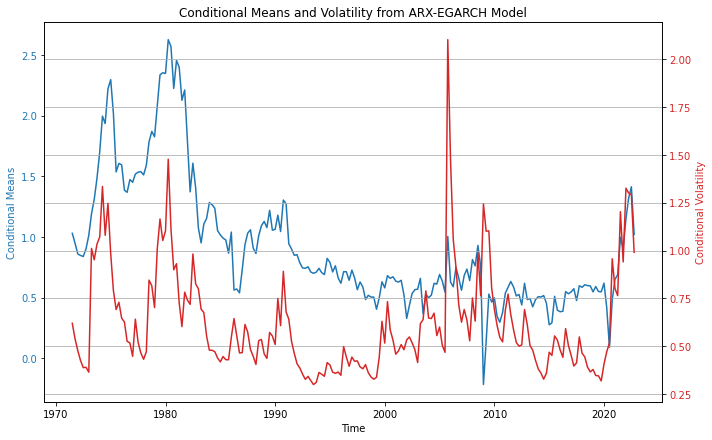

In [46]:
mu = gjr_garch21.params['Const']
ar1_coef = gjr_garch21.params['Inflation[1]']
ar2_coef = gjr_garch21.params['Inflation[2]']
exog1_coef = gjr_garch21.params['Forecasted inflation']
exog2_coef = gjr_garch21.params['Forecasted_inflation_lag_1']

# Calculate the conditional means
conditional_means = mu + ar1_coef * sample_data['Inflation'].shift(1) + ar2_coef * sample_data['Inflation'].shift(2) + exog1_coef * sample_data['Forecasted inflation'] + exog2_coef * sample_data['Forecasted_inflation_lag_1']
print("Correlation bewteen conditional mean and conditional volatiliy is ", np.corrcoef(conditional_means[3:], gjr_garch21.conditional_volatility[3:])[0, 1])

# Plotting both the series
fig, ax1 = plt.subplots(figsize=(10,6))

color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Conditional Means', color=color)
ax1.plot(conditional_means, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Conditional Volatility', color=color)  # we already handled the x-label with ax1
ax2.plot(gjr_garch21.conditional_volatility, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Conditional Means and Volatility from ARX-EGARCH Model')
plt.grid(True)
plt.show()


In [6]:
from __future__ import annotations
from arch.univariate.distribution import Distribution
from abc import ABCMeta, abstractmethod
from collections.abc import Sequence
from typing import Callable
import warnings

from numpy import (
    abs,    array,    asarray,    empty,    exp,    int64,    
    integer,    isscalar,    log,    nan,    ndarray, exp,
    ones_like,    pi,    sign,    sqrt,    sum, random)
from numpy.random import Generator, RandomState, default_rng
from scipy.special import comb, gamma, gammainc, gammaincc, gammaln
import scipy.stats as stats
from scipy.optimize import bisect

from arch.typing import ArrayLike, ArrayLike1D, Float64Array
from arch.utility.array import AbstractDocStringInheritor, ensure1d

class MixNormal(Distribution, metaclass=AbstractDocStringInheritor):
    """
    Mixture of two Normal distributions for use with SPARCH model

    Parameters
    ----------
    random_state : RandomState, optional
        .. deprecated:: 5.0

           random_state is deprecated. Use seed instead.

    seed : {int, Generator, RandomState}, optional
        Random number generator instance or int to use. Set to ensure
        reproducibility. If using an int, the argument is passed to
        ``np.random.default_rng``.  If not provided, ``default_rng``
        is used with system-provided entropy.
    """

    def __init__(
        self,
        random_state: RandomState | None = None,
        *,
        seed: None | int | RandomState | Generator = None,
    ) -> None:
        super().__init__(random_state=random_state, seed=seed)
        self._name = "Mixture of two Normal distributions"
        self.num_params: int = 3  

    def constraints(self) -> tuple[Float64Array, Float64Array]:
        return empty(0), empty(0)
        #return array([[1, 0, 0], [-1, 0, 0], [0, 1,0], [0, -1,0] , [0,0,1],[0,0,-1]]), array([0.05, 0.95, -20,20,0.2, 10])

    def bounds(self, resids: Float64Array) -> list[tuple[float, float]]:
        """
        Bounds of parameters:
        p1: (0,1)
        u1: (-10,10)
        sigma_1:(0.001,10)
        """
        return [(0.0001, 0.9999),(-10000,10000),(0.0001, 10000)]

    def loglikelihood(
        self,
        parameters: Sequence[float] | ArrayLike1D,
        resids: ArrayLike,
        sigma2: ArrayLike,
        individual: bool = False,
    ) -> float | Float64Array:
        r"""Computes the log-likelihood of assuming residuals are mixture normally
        distributed, conditional on the variance

        Parameters
        ----------
        parameters : ndarray
            Parameters of the first normal distribution: p1,u1,sigma1. Second one can be calculated by restrictions.
        resids  : ndarray
            The residuals to use in the log-likelihood calculation
        sigma2 : ndarray
            Conditional variances of resids
        individual : bool, optional
            Flag indicating whether to return the vector of individual log
            likelihoods (True) or the sum (False)

        Returns
        -------
        ll : float
            The log-likelihood

        Notes
        -----
        The log-likelihood of a single data point x is

        .. math::

            \ln f\left(x\right)=
            \ln \frac{1}{\sqrt{h_t}} \left[
                 p_1  \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(x-\mu_1)^2}{2\sigma_1^2} \}
                +(1-p_1)\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(x-\mu_2)^2}{2\sigma_2^2} \} \right]

        """
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        z = resids/sqrt(sigma2)
        warnings.filterwarnings("ignore")
        lls =-1/2 *log(sigma2) +  log(   p1/(sqrt(2*pi*sigma_1_2)) *  exp(-( z-u1)**2/(2*sigma_1_2)) 
                                     +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
        warnings.filterwarnings("default")
          
        if individual:
            return lls
        else:
            return sum(lls)

    def starting_values(self, std_resid: Float64Array) -> Float64Array:
        """
        Starting values of parameters
        """
        #gmm = GaussianMixture(n_components=2).fit(std_resid.reshape(-1,1))
        #return array([gmm.weights_[0],gmm.means_[0][0], gmm.covariances_[0][0][0] ])
        return array([0.3, 0.1,1])
    
    def _simulator(self, size: int | tuple[int, ...]) -> Float64Array:
        assert self._parameters is not None
        p1, u1, sigma_1_2 = self._parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        Z = np.random.binomial(n=1, p=p1, size=size)
        return sqrt(sigma_1_2)**Z*sqrt(sigma_2_2)**(1-Z)*self._generator.standard_normal(size) + u1*Z+ u2*(1-Z)

    def simulate(
        self, parameters: int | float | Sequence[float | int] | ArrayLike1D
    ) -> Callable[[int | tuple[int, ...]], Float64Array]:
        parameters = ensure1d(parameters, "parameters", False)
        self._parameters = asarray(parameters, dtype=float)
        return self._simulator

    def parameter_names(self) -> list[str]:
        return ['p_1','mu_1','sigma_1^2']

    def cdf(
        self,
        resids: Sequence[float] | ArrayLike1D,
        parameters: None | Sequence[float] | ArrayLike1D = None,
    ) -> Float64Array:
        self._check_constraints(parameters)
        
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        return p1*stats.norm.cdf(asarray((resids-u1)/sqrt(sigma_1_2))  ) + p2*stats.norm.cdf(asarray((resids-u2)/sqrt(sigma_2_2)))

    def ppf(
        self,
        pits: float | Sequence[float] | ArrayLike1D,
        parameters: None | Sequence[float] | ArrayLike1D = None,
    ) -> Float64Array:
        self._check_constraints(parameters)
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        scalar = isscalar(pits)
        if scalar:
            pits = array([pits])
        else:
            pits = asarray(pits)
            
        def inverse_cdf(cdf, target_p, lower_bound=-100, upper_bound=100):
            def root_func(x):
                return cdf(x,parameters) - target_p
            return bisect(root_func, lower_bound, upper_bound)     
        
        ppf = inverse_cdf(self.cdf, pits, lower_bound=-100, upper_bound=100)

        if scalar:
            return ppf[0]
        else:
            return ppf

    def moment(
        self, n: int, parameters: None | Sequence[float] | ArrayLike1D = None
    ) -> float:
        if n < 0:
            return nan
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        moment1 = stats.norm.moment(n,loc=u1,scale=sqrt(sigma_1_2))
        moment2 = stats.norm.moment(n,loc=u2,scale=sqrt(sigma_2_2))
        return p1 * moment1 + p2 * moment2

    def partial_moment(
        self,
        n: int,
        z: float = 0.0,
        parameters: None | Sequence[float] | ArrayLike1D = None,
        num_samples=1000,
    ) -> float:
        
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        if n < 0:
            return nan
        elif n == 0:
            return cdf(z,parameters)
        elif n==1:
            return -p1*stats.norm.pdf(z,loc=u1,scale=sqrt(sigma_1_2))  -p2*stats.norm.pdf(z,loc=u2,scale=sqrt(sigma_2_2))
        else:
            -(z ** (n - 1)) * (p1*stats.norm.pdf(z,loc=u1,scale=sqrt(sigma_1_2))+p2*stats.norm.pdf(z,loc=u2,scale=sqrt(sigma_2_2))) 
            + (n - 1) * self.partial_moment(  n - 2, z, parameters  )

In [8]:
def SPARCH(Y,dparams,X=None,mean='Zero', vol='GARCH',p=1,o=0,q=1,lags=None,cov = 'robust'):
    '''
    step 1: run a garch with student t distribution; estimate gaussian mixture parameters from garch residuals
    step 2: run a sparch using garch parameters
    '''
    #run GARCH with student t distribuion as banchmark
    garht = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=p, o=o,q=q,lags=lags,dist='studentst').fit(disp='off',cov_type=cov)
    params = array(garht.params) +   0.1*array(garht.std_err)*np.random.normal(size=garht.std_err.shape)
    starting_values = np.concatenate( (np.array(params)[:-1],dparams )   )
    constraints = {'type': 'ineq',
                'fun': lambda x: array([ 0.9999 - x[-3] * (x[-2]**2 + x[-1]) - (1 - x[-3]) * (-x[-3] * x[-2] / (1 - x[-3]))**2])} 
    options={'maxiter': 1000,'constraints':constraints}
    sparch = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=p, o=o,q=q,lags=lags)
    sparch.distribution = MixNormal()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        MixNormalres=sparch.fit(disp='off',cov_type=cov,options=options,starting_values=starting_values )
    return MixNormalres